# Cost of Living for International Students in Europe

**Author:** Emirhan Ömer  
**Date:** May 2026

## Motivation

As an international student living in Turin, I wanted to understand how
European cities compare not only in absolute cost of living, but in **real
affordability** — how much of an average income basic expenses actually
consume. The question becomes more interesting when we ask the same about
international students, who typically live on a fraction of the local
median wage.

## Research questions

1. Which European cities have the most favorable cost-to-income ratio for
   their local residents?
2. How does Turin compare to other major European student hubs?
3. Does the picture change when we view the same data through a student's
   budget instead of the local average wage?

## Data source

[Global Cost of Living dataset](https://www.kaggle.com/datasets/mvieira101/global-cost-of-living)
on Kaggle, sourced from Numbeo (May 2022 snapshot). 4,874 cities × 55
price-level columns, plus a `data_quality` flag indicating whether Numbeo
considers the entry well-supported by enough contributors.

## Approach

A short EDA followed by the construction of a composite "monthly cost"
metric and an affordability ratio. I then run the same metric under two
different income scenarios (local average salary, and a fixed 1000 USD
international student budget) to surface how the same city can look very
different depending on whose perspective you use.

## 1. Loading the dataset

First look — shape, column structure, and missing-value pattern. The
dataset uses anonymized column names (`x1` to `x55`) which map to specific
Numbeo items (meals, groceries, rent, transport, salary). A data dictionary
is provided on the Kaggle page and I'll reference it by category as I go.

In [23]:
import pandas as pd
import numpy as np

df = pd.read_csv('data/cost-of-living.csv')
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head()


Shape: (4874, 59)

Columns: ['Unnamed: 0', 'city', 'country', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22', 'x23', 'x24', 'x25', 'x26', 'x27', 'x28', 'x29', 'x30', 'x31', 'x32', 'x33', 'x34', 'x35', 'x36', 'x37', 'x38', 'x39', 'x40', 'x41', 'x42', 'x43', 'x44', 'x45', 'x46', 'x47', 'x48', 'x49', 'x50', 'x51', 'x52', 'x53', 'x54', 'x55', 'data_quality']


,Unnamed: 0,city,country,x1,x2,x3,x4,x5,x6,x7,...,x47,x48,x49,x50,x51,x52,x53,x54,x55,data_quality
0,0,Delhi,India,4.90,22.04,4.28,1.84,3.67,1.78,0.48,...,36.26,223.87,133.38,596.16,325.82,2619.46,1068.90,586.35,7.96,1
1,1,Shanghai,China,5.59,40.51,5.59,1.12,4.19,3.96,0.52,...,121.19,1080.07,564.30,2972.57,1532.23,17333.09,9174.88,1382.83,5.01,1
2,2,Jakarta,Indonesia,2.54,22.25,3.50,2.02,3.18,2.19,0.59,...,80.32,482.85,270.15,1117.69,584.37,2694.05,1269.44,483.19,9.15,1
3,3,Manila,Philippines,3.54,27.40,3.54,1.24,1.90,2.91,0.93,...,61.82,559.52,281.78,1754.40,684.81,3536.04,2596.44,419.02,7.80,1
4,4,Seoul,South Korea,7.16,52.77,6.03,3.02,4.52,3.86,1.46,...,108.30,809.83,583.60,2621.05,1683.74,21847.94,10832.90,2672.23,3.47,1


In [24]:
# 1. Genel bakış
df.info()

# 2. İstatistiksel özet (sayısal sütunlar)
df.describe()

# 3. Missing values
df.isnull().sum().sort_values(ascending=False).head(20)

# 4. Bu dataset'te kaç tane Avrupa şehri var?
# (önce hangi sütun şehir/ülke içeriyor onu bul)
df['city'].nunique() if 'city' in df.columns else df.head(2)

# 5. Turin var mı? Milano var mı?
df[df['city'].str.contains('Turin|Torino|Milan', case=False, na=False)] \
    if 'city' in df.columns else "city sütununu bulamadım"

<class 'pandas.DataFrame'>
RangeIndex: 4874 entries, 0 to 4873
Data columns (total 59 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Unnamed: 0    4874 non-null   int64  
 1   city          4874 non-null   str    
 2   country       4874 non-null   str    
 3   x1            4449 non-null   float64
 4   x2            4432 non-null   float64
 5   x3            4552 non-null   float64
 6   x4            4385 non-null   float64
 7   x5            4445 non-null   float64
 8   x6            4540 non-null   float64
 9   x7            4438 non-null   float64
 10  x8            4571 non-null   float64
 11  x9            4494 non-null   float64
 12  x10           4457 non-null   float64
 13  x11           4538 non-null   float64
 14  x12           4369 non-null   float64
 15  x13           4393 non-null   float64
 16  x14           4318 non-null   float64
 17  x15           4312 non-null   float64
 18  x16           4509 non-null   float64
 

,Unnamed: 0,city,country,x1,x2,x3,x4,x5,x6,x7,...,x47,x48,x49,x50,x51,x52,x53,x54,x55,data_quality
326,326,Milan,Italy,20.77,83.10,9.61,6.23,5.19,1.84,2.73,...,157.40,1304.32,856.00,2689.48,1746.49,8983.21,4691.45,1868.62,1.66,1
601,601,Turin,Italy,13.50,54.53,9.35,5.19,4.15,1.49,2.28,...,106.06,565.29,433.03,1343.81,794.88,3414.28,1761.95,1606.70,1.77,1
860,860,Maturin,Venezuela,8.00,30.00,10.25,1.25,2.25,1.25,1.00,...,120.00,100.00,120.00,250.00,300.00,NaN,NaN,260.00,15.60,0


In [25]:
# Turin/Torino, Milano, Berlin var mı?
df[df['city'].str.contains('Turin|Torino|Milan|Berlin|Madrid', case=False, na=False)][['city', 'country']]

# Toplam İtalya şehri sayısı
print("İtalya şehri:", (df['country'] == 'Italy').sum())
print("Almanya şehri:", (df['country'] == 'Germany').sum())

İtalya şehri: 185
Almanya şehri: 147


In [26]:
european_countries = ['Italy', 'Germany', 'France', 'Spain', 'Netherlands', 
                      'Portugal', 'Belgium', 'Austria', 'Poland', 'Czech Republic',
                      'United Kingdom', 'Ireland', 'Denmark', 'Sweden']

eu = df[df['country'].isin(european_countries)]
print("Toplam Avrupa şehri:", len(eu))
print("data_quality=1 olan:", (eu['data_quality'] == 1).sum())

turin = df[df['city'].str.contains('Turin|Torino', case=False, na=False)]
print("\nTurin satırı:")
print(turin[['city', 'country', 'data_quality', 'x48', 'x54']])

Toplam Avrupa şehri: 984
data_quality=1 olan: 248

Turin satırı:
        city    country  data_quality     x48     x54
601    Turin      Italy             1  565.29  1606.7
860  Maturin  Venezuela             0  100.00   260.0


## 2. Filtering: quality and scope

Two filters before any analysis:

- **Geographic scope:** I focus on 14 Western and Central European countries
  to keep the comparison meaningful. Of the **984 European cities** in the
  dataset, only **248 have `data_quality = 1`** — meaning Numbeo considers
  there are enough contributors to trust the values. The other ~75% are
  dropped.

- **Focus cities:** From the 248 quality-checked European cities I selected
  11 major student hubs across 7 countries: Turin, Milan, Rome, Berlin,
  Munich, Paris, Madrid, Barcelona, Amsterdam, Lisbon, Vienna. (Prague was
  initially considered but the entry was missing from the quality-filtered
  subset, so I dropped it rather than weakening the comparison with a
  lower-quality row.)

A note on a small data-cleaning catch: my first attempt used
`str.contains('Turin')`, which also matched **Maturin, Venezuela**. A good
reminder that substring matching can pick up things you didn't ask for —
I switched to exact matching with `isin()`.

In [27]:
# Hedef şehirler — Avrupa'nın büyük öğrenci hub'ları
target_cities = [
    'Turin', 'Milan', 'Rome',           # İtalya
    'Berlin', 'Munich',                  # Almanya
    'Paris',                             # Fransa
    'Madrid', 'Barcelona',               # İspanya
    'Amsterdam',                         # Hollanda
    'Lisbon',                            # Portekiz
    'Prague',                            # Çekya
    'Vienna'                             # Avusturya
]

# Bu şehirleri bul + data_quality=1 filtresi
focus = df[
    (df['city'].isin(target_cities)) & 
    (df['data_quality'] == 1)
].copy()

print("Bulunan şehir sayısı:", len(focus))
print("\nŞehirler:")
print(focus[['city', 'country', 'x48', 'x49', 'x54']].sort_values('city'))

Bulunan şehir sayısı: 11

Şehirler:
          city      country      x48      x49      x54
456  Amsterdam  Netherlands  1769.11  1512.73  3606.11
114  Barcelona        Spain  1075.89   840.13  1924.32
144     Berlin      Germany  1307.95   953.36  3086.47
476     Lisbon     Portugal  1215.82   801.79  1099.90
81      Madrid        Spain  1041.06   827.49  2022.60
326      Milan        Italy  1304.32   856.00  1868.62
307     Munich      Germany  1407.34  1077.20  3435.65
29       Paris       France  1325.47   978.26  2741.22
172       Rome        Italy  1055.02   717.64  1549.17
601      Turin        Italy   565.29   433.03  1606.70
247     Vienna      Austria   983.06   690.86  2662.28


## 3. Designing an affordability metric

I built a "monthly basic cost of living" by summing six categories:

| Category   | Columns used         | Why |
|------------|----------------------|-----|
| Rent       | x48 (1-bedroom, centre) | Typical student profile |
| Utilities  | x36 (electricity/water/heating) | Fixed monthly bill |
| Internet   | x38                  | Fixed monthly bill |
| Transport  | x29 (monthly transit pass) | Realistic student commute |
| Groceries  | x9, x10, x12, x14, x16, x19, x20 with monthly multipliers | Basic kitchen |
| Social     | x1 × 4 + x6 × 8 (4 cheap meals out, 8 coffees) | Minimum social life |

**Key assumptions** (worth being explicit about):

- Grocery multipliers are my own estimates of monthly consumption (e.g.,
  10 loaves of bread, 4 liters of milk, 2 kg of chicken). These are
  defensible but not measured — a sensitivity analysis would be the next
  step in a longer project.
- "Social" is intentionally minimal. A more lifestyle-driven version of the
  metric would push these values up considerably and would change the
  ranking somewhat.
- All values are in USD as provided by Numbeo; no currency conversion was
  applied.

The **affordability ratio** is then `monthly_cost / x54` (average net
salary). A value below 1 means basic living costs less than the average
local wage; above 1 means the opposite.

In [28]:
# Aylık tüketim katsayıları — tüm market kalemleri "kg" veya "adet" başına
# o yüzden kendi tahminimle aylık miktarlara çeviriyorum
monthly_grocery = (
    focus['x9']  * 10   +   # Süt: 10 litre
    focus['x10'] * 20  +   # Ekmek: 20 adet (500g)
    focus['x12'] * 4   +   # Yumurta: 4 düzine
    focus['x14'] * 10   +   # Tavuk: 10 kg
    focus['x16'] * 5   +   # Elma: 5 kg
    focus['x19'] * 5   +   # Domates: 5 kg
    focus['x20'] * 6       # Patates: 6 kg
)

# Sosyal: ayda 7 ucuz restoran + 10 kahve
monthly_social = focus['x1'] * 7 + focus['x6'] * 10

# Toplam aylık temel yaşam maliyeti
focus['monthly_cost'] = (
    focus['x48']    +   # Kira
    focus['x36']    +   # Faturalar
    focus['x38']    +   # İnternet
    focus['x29']    +   # Aylık ulaşım
    monthly_grocery +
    monthly_social
)

# Affordability oranı: maaşın ne kadarını yiyor?
focus['affordability_ratio'] = focus['monthly_cost'] / focus['x54']

# Sıralı tablo — en yaşanabilir üstte
result = focus[['city', 'country', 'monthly_cost', 'x54', 'affordability_ratio']] \
    .sort_values('affordability_ratio') \
    .round(2)

print(result.to_string(index=False))

     city     country  monthly_cost     x54  affordability_ratio
   Vienna     Austria       1624.60 2662.28                 0.61
   Munich     Germany       2160.87 3435.65                 0.63
   Berlin     Germany       2054.42 3086.47                 0.67
    Turin       Italy       1122.73 1606.70                 0.70
Amsterdam Netherlands       2565.35 3606.11                 0.71
    Paris      France       2020.41 2741.22                 0.74
   Madrid       Spain       1548.73 2022.60                 0.77
Barcelona       Spain       1603.44 1924.32                 0.83
    Milan       Italy       1970.62 1868.62                 1.05
     Rome       Italy       1636.13 1549.17                 1.06
   Lisbon    Portugal       1665.34 1099.90                 1.51


## 4. Finding 1 — Affordability across Europe (local-wage view)

The first chart shows the affordability ratio for an average local resident
in each of the 11 cities. Colors group the cities into three regimes:

- **Green (< 0.70):** Vienna, Munich, Berlin — high local wages absorb high
  costs comfortably. These are the most "livable" by this metric.
- **Orange (0.70 – 1.00):** Turin, Amsterdam, Paris, Madrid, Barcelona — a
  middle band where basic costs eat 70–85% of the average wage. Doable, but
  not generous.
- **Red (> 1.00):** Milan, Rome, Lisbon — basic costs exceed the average
  net salary. **Lisbon is the outlier at 1.51**, meaning the average net
  wage doesn't cover even basic expenses on this definition.

A surprising finding: cities I would have intuitively labeled "cheap"
(Lisbon, Rome) turn out to be the hardest to live in *for the people who
live there* — because wages haven't kept up with rent and groceries.
Absolute price levels and affordability are very different things.

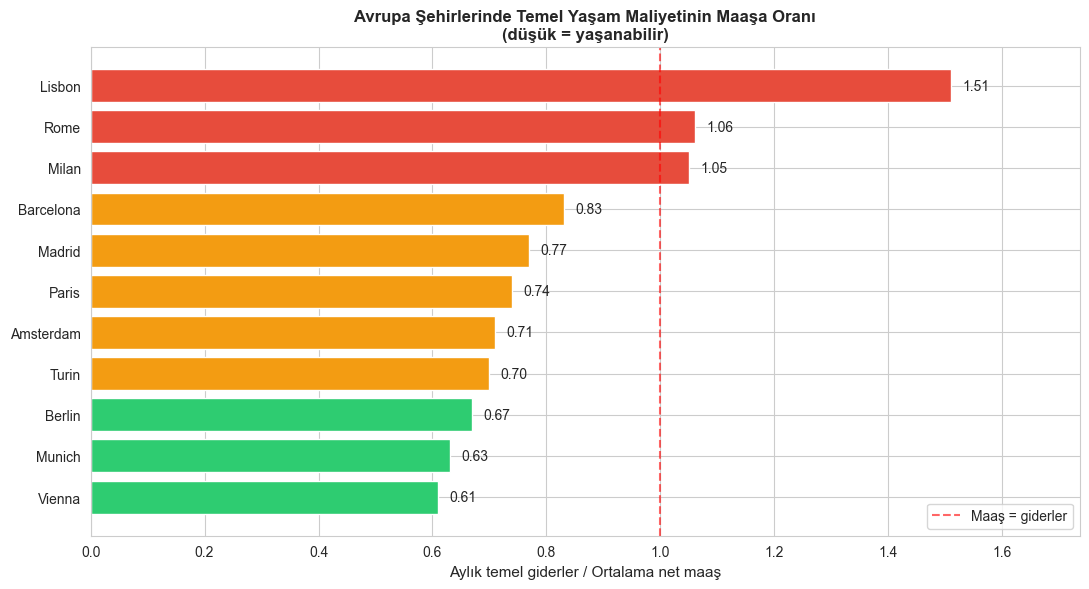

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns

# Stil
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (11, 6)

# Sıralı veri (en yaşanabilir üstte → en zor altta)
plot_data = result.sort_values('affordability_ratio', ascending=True)

# Renk: oran <1 yeşil tonu, oran >1 kırmızı (maaş yetmiyor)
colors = ['#2ecc71' if r < 0.7 else '#f39c12' if r < 1.0 else '#e74c3c' 
          for r in plot_data['affordability_ratio']]

# Çiz
fig, ax = plt.subplots()
bars = ax.barh(plot_data['city'], plot_data['affordability_ratio'], color=colors)

# %100 maaş çizgisi (kritik referans)
ax.axvline(x=1.0, color='red', linestyle='--', alpha=0.6, label='Maaş = giderler')

# Bar'ların ucuna oran yaz
for bar, ratio in zip(bars, plot_data['affordability_ratio']):
    ax.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
            f'{ratio:.2f}', va='center', fontsize=10)

ax.set_xlabel('Aylık temel giderler / Ortalama net maaş', fontsize=11)
ax.set_title('Avrupa Şehirlerinde Temel Yaşam Maliyetinin Maaşa Oranı\n(düşük = yaşanabilir)', 
             fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim(0, max(plot_data['affordability_ratio']) * 1.15)

plt.tight_layout()
plt.savefig('images/affordability_ratio.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Finding 2 — Absolute amounts: who actually saves money?

Ratios can hide absolute scale. The same affordability ratio of 0.70 means
something very different when the underlying numbers are 700/1000 vs
2500/3500. So I plotted average salary and monthly cost side by side in
USD.

The picture shifts: the **biggest gap (= savings potential) is in Munich,
Vienna, Berlin, and Amsterdam** — all in the 1200–1500 USD/month range
left over. Turin, despite its excellent ratio, ends up only **5th–6th in
absolute savings potential** because both salary and costs are low. Lisbon
is now visibly broken: salary doesn't even cover the bar of basic costs.

This is the classic "ratio vs absolute" tradeoff. A single metric is rarely
enough.

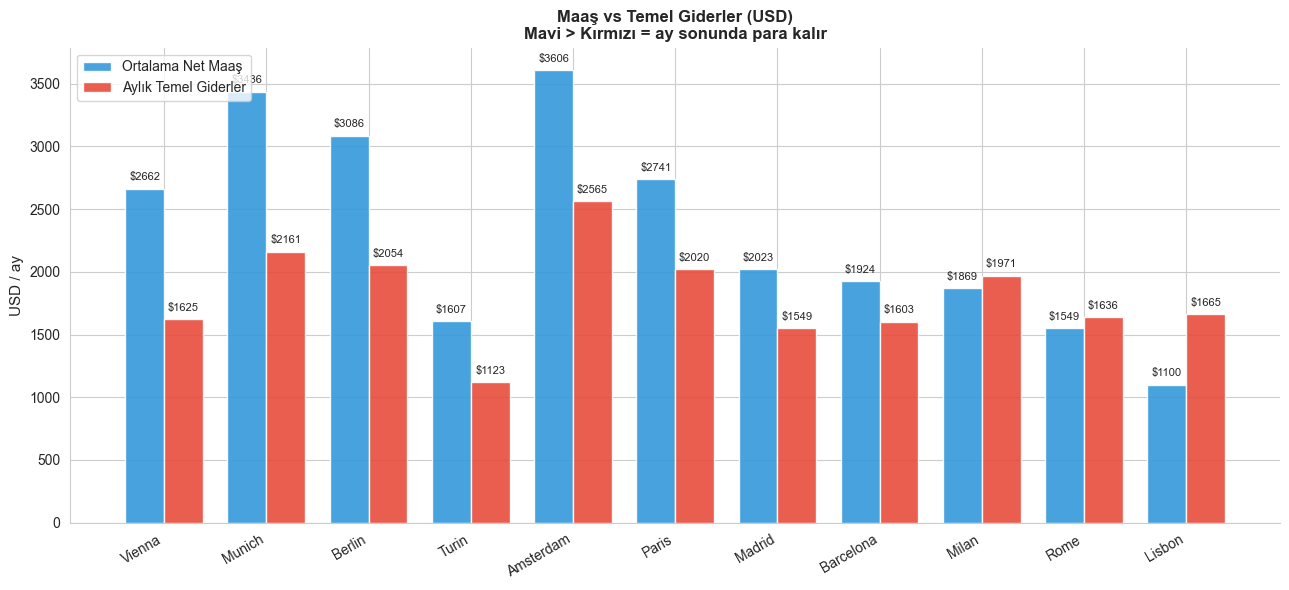

In [30]:
import numpy as np

# Sıralı (en yaşanabilir → en zor)
plot_data = result.sort_values('affordability_ratio')

cities = plot_data['city'].values
costs = plot_data['monthly_cost'].values
salaries = plot_data['x54'].values

x = np.arange(len(cities))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, salaries, width, label='Ortalama Net Maaş', 
               color='#3498db', alpha=0.9)
bars2 = ax.bar(x + width/2, costs, width, label='Aylık Temel Giderler', 
               color='#e74c3c', alpha=0.9)

# Bar tepelerine değer yaz
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 50,
                f'${h:.0f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(cities, rotation=30, ha='right')
ax.set_ylabel('USD / ay', fontsize=11)
ax.set_title('Maaş vs Temel Giderler (USD)\nMavi > Kırmızı = ay sonunda para kalır',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('images/absolute_costs.png', dpi=150, bbox_inches='tight')
plt.show()

In [31]:
# Her şehir için aylık birikim potansiyeli (maaş - giderler)
result['monthly_savings'] = result['x54'] - result['monthly_cost']
print(result.sort_values('monthly_savings', ascending=False)[['city', 'monthly_cost', 'x54', 'monthly_savings']].round(0).to_string(index=False))

     city  monthly_cost    x54  monthly_savings
   Munich        2161.0 3436.0           1275.0
Amsterdam        2565.0 3606.0           1041.0
   Vienna        1625.0 2662.0           1038.0
   Berlin        2054.0 3086.0           1032.0
    Paris        2020.0 2741.0            721.0
    Turin        1123.0 1607.0            484.0
   Madrid        1549.0 2023.0            474.0
Barcelona        1603.0 1924.0            321.0
     Rome        1636.0 1549.0            -87.0
    Milan        1971.0 1869.0           -102.0
   Lisbon        1665.0 1100.0           -565.0


In [32]:
# Öğrenci senaryosu: herkesin geliri sabit 1000 USD
STUDENT_BUDGET = 1000

# Yeni oran: aylık gider / 1000 USD bütçe
result['student_ratio'] = result['monthly_cost'] / STUDENT_BUDGET

# Karşılaştırma için iki oranı yan yana göster
comparison = result[['city', 'monthly_cost', 'affordability_ratio', 'student_ratio']] \
    .sort_values('student_ratio') \
    .round(2)

print("Öğrenci (1000 USD bütçe) vs Lokal çalışan (ortalama maaş) karşılaştırması:")
print(comparison.to_string(index=False))

Öğrenci (1000 USD bütçe) vs Lokal çalışan (ortalama maaş) karşılaştırması:
     city  monthly_cost  affordability_ratio  student_ratio
    Turin       1122.73                 0.70           1.12
   Madrid       1548.73                 0.77           1.55
Barcelona       1603.44                 0.83           1.60
   Vienna       1624.60                 0.61           1.62
     Rome       1636.13                 1.06           1.64
   Lisbon       1665.34                 1.51           1.67
    Milan       1970.62                 1.05           1.97
    Paris       2020.41                 0.74           2.02
   Berlin       2054.42                 0.67           2.05
   Munich       2160.87                 0.63           2.16
Amsterdam       2565.35                 0.71           2.57


## 5. Finding 2 — Absolute amounts: who actually saves money?

Ratios can hide absolute scale. The same affordability ratio of 0.70 means
something very different when the underlying numbers are 700/1000 vs
2500/3500. So I plotted average salary and monthly cost side by side in
USD.

The picture shifts: the **biggest gap (= savings potential) is in Munich,
Vienna, Berlin, and Amsterdam** — all in the 1200–1500 USD/month range
left over. Turin, despite its excellent ratio, ends up only **5th–6th in
absolute savings potential** because both salary and costs are low. Lisbon
is now visibly broken: salary doesn't even cover the bar of basic costs.

This is the classic "ratio vs absolute" tradeoff. A single metric is rarely
enough.

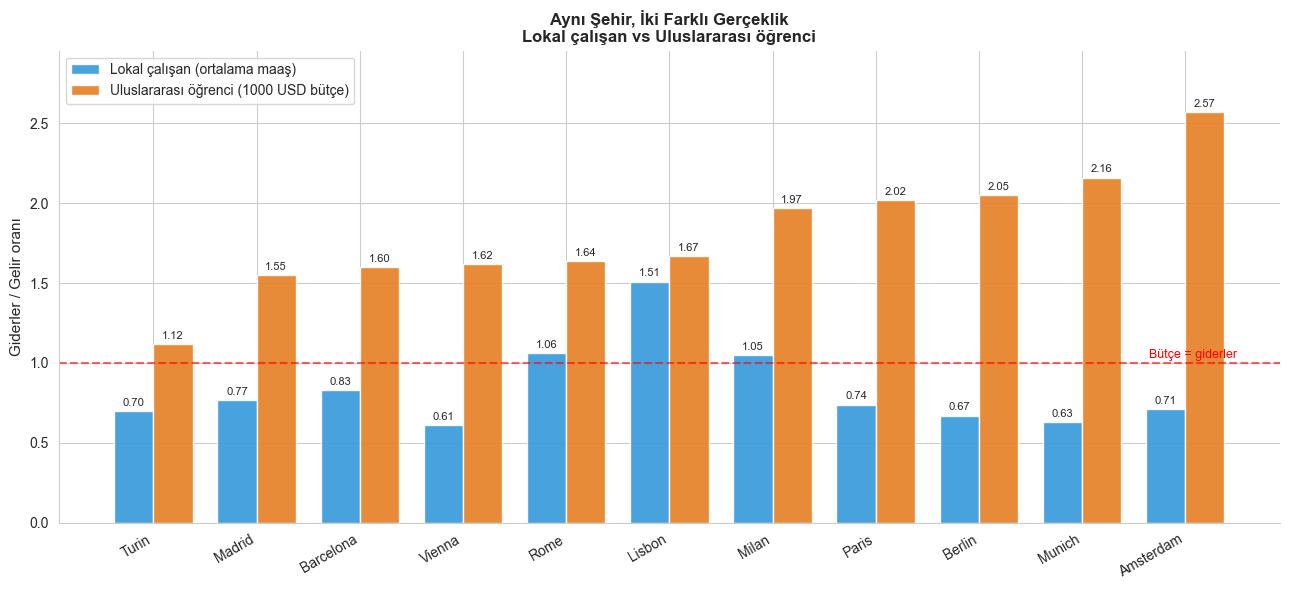

In [33]:
plot_data = comparison.sort_values('student_ratio', ascending=True)

cities = plot_data['city'].values
local = plot_data['affordability_ratio'].values
student = plot_data['student_ratio'].values

x = np.arange(len(cities))
width = 0.38

fig, ax = plt.subplots(figsize=(13, 6))
bars1 = ax.bar(x - width/2, local, width, 
               label='Lokal çalışan (ortalama maaş)', color='#3498db', alpha=0.9)
bars2 = ax.bar(x + width/2, student, width, 
               label='Uluslararası öğrenci (1000 USD bütçe)', color='#e67e22', alpha=0.9)

# %100 kritik çizgi
ax.axhline(y=1.0, color='red', linestyle='--', alpha=0.6, linewidth=1.5)
ax.text(len(cities)-0.5, 1.03, 'Bütçe = giderler', color='red', fontsize=9, ha='right')

# Bar tepelerine değer yaz
for bars in [bars1, bars2]:
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.02,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(cities, rotation=30, ha='right')
ax.set_ylabel('Giderler / Gelir oranı', fontsize=11)
ax.set_title('Aynı Şehir, İki Farklı Gerçeklik\nLokal çalışan vs Uluslararası öğrenci', 
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.set_ylim(0, max(student) * 1.15)

plt.tight_layout()
plt.savefig('images/local_vs_student.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Limitations

A short, honest list — these matter when reading the chart:

- **Source bias:** Numbeo is crowd-sourced. Even with `data_quality = 1`,
  values reflect contributor demographics (often expats, often
  city-centre), not full markets.
- **Snapshot:** The dataset is from May 2022. Rents in Lisbon, Berlin,
  Amsterdam in particular have moved significantly since.
- **Average salary is a rough proxy** for "typical local". It hides
  inequality within the city.
- **Student budget is a single fixed number** — in reality the 1000 USD
  varies by program, country, and family situation. A small sensitivity
  analysis (try 800 / 1000 / 1200) would strengthen the conclusion.
- **My grocery multipliers are not validated** against survey data; they
  are reasonable but personal.
- **No purchasing-power adjustment** beyond what's already in USD-converted
  Numbeo values.

## 8. Conclusion

Three findings worth keeping:

1. **Cheap on paper ≠ affordable in practice.** Lisbon and Rome look
   inexpensive in absolute terms but are the hardest to live in for
   locals.
2. **Absolute and relative views can disagree.** Turin is the most
   affordable city by ratio but middle-of-the-pack by absolute savings.
3. **Affordability depends on whose income you use.** The same data tells
   a near-opposite story for locals vs international students. For
   students, no city in this set is structurally affordable on a fixed
   1000 USD budget.

A natural next step would be to layer in 2024–2025 rent data from sources
like Idealista or Immobiliare and re-run the analysis with current numbers.